### Classification en NLP simple : spam ou non-spam (multilingue en/fr)
- Auteur : NY Aina Tendrisoa Andrinina (etudiant en Intelligence artifielle et data science)
- Dataset : data-en-hi-de-fr.csv
- Feature : text
- Target : labels
- Modeles a tester : Regression logistique, SVM, k-NN 

#### 1- EDA (exploratory data analysis)

In [11]:
#importation des bibliotheques et modules

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import re
import nltk
from nltk.corpus import stopwords
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [2]:
#chargement du dataset 

df_message = pd.read_csv("../Datas/data-en-hi-de-fr.csv")

df_message_fr = df_message[["labels", "text_fr"]]
df_message_fr = df_message_fr.rename(columns={'text_fr' : 'text'})
df_message_en = df_message[["labels", "text"]]

df_message = pd.concat([df_message_en, df_message_fr], ignore_index=True)

In [3]:
#info sur le jeu des donnees

df_message.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11144 entries, 0 to 11143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   labels  11144 non-null  object
 1   text    11144 non-null  object
dtypes: object(2)
memory usage: 174.3+ KB


In [4]:
df_message.head()

,labels,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
#verifie les valeurs manquantes

df_message.isnull().sum()

labels    0
text      0
dtype: int64

In [6]:
#verifie les doublons

df_message.duplicated().sum()

np.int64(876)

In [7]:
#suppimer les doublons

df_message = df_message.drop_duplicates()

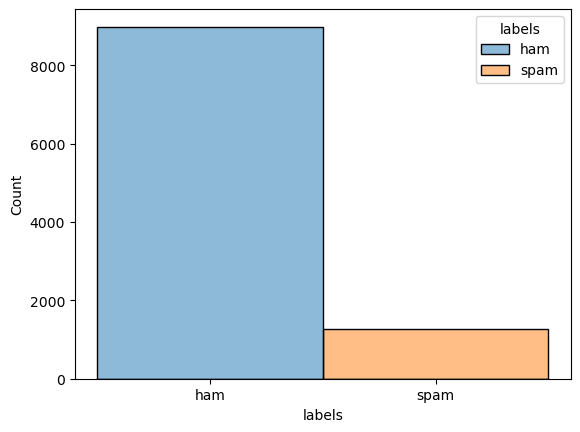

In [8]:
#voir la distribution des classes

sns.histplot(df_message, x="labels", hue="labels")
plt.show()

#### 2- Normalisation des textes

In [67]:
stop_words_en = stopwords.words('english')
stop_words_fr = stopwords.words('french')

nlp_en = spacy.load("en_core_web_sm")
nlp_fr = spacy.load("fr_core_news_sm")


#https://www.codeandcortex.fr/spacy-natural-langage-process-lemmatisation/
def cleaner_lemmatizer(message):
    message = message.lower() # on transforme en minuscule tous les lettres
    message = re.sub(r"['|-]",' ', message) # on remplace [' | -] par les espaces
    message = re.sub(r'http\S+|www\S+', '<url>', message) # on remplace tous les url par un token <url>
    message = re.sub(r'\w+.@\w+.\w+', '<email>', message) # on remplace aussi les email par <email>
    message = re.sub(r'\+\s?\d+', '<numero mobile>', message) # on remplace aussi les numeros par <numero mobile>


    # montants avec devises ($, €, £, etc.)
    message = re.sub(r'[\$€£¥]\s*[\d\s,\.]+', '<montant>', message)
    message = re.sub(r'[\d\s,\.]+\s*[\$€£¥]', '<montant>', message)
    message = re.sub(r'\b\d[\d\s,\.]*\s*(dollars?|euros?|pounds?|yen|francs?|usd|eur|gbp)\b', '<montant>', message, flags=re.IGNORECASE)

    message = re.sub(r'\b\d+\s*(st|nd|rd|th|ème|eme|er|ère|ere)\b', '<ordinal>', message, flags=re.IGNORECASE) # ordre

    message = re.sub(r'\b\d[\d\s,\.]*\s*%', '<pourcentage>', message) # pourcentage

    message = re.sub(r'\b\w*\d+\w*\b', '<chiffre>', message) # chiffres restants sans devise
    message = re.sub(r'[^\w\s]', '', message) # on supprime les ponctuations

    list_words = message.split()
    
    score_langue = {'en' : 0, 'fr' : 0}

    for word in list_words:
        for stop_word in stop_words_en:
            if word == stop_word:
                score_langue['en'] += 1
        for stop_word in stop_words_fr:
            if word == stop_word:
                score_langue['fr'] += 1
            
    if score_langue['en'] > score_langue['fr']:
        langue_detecte = 'en'
        list_words = [word for word in list_words if word not in stop_words_en]
        list_words = ' '.join(list_words)

    else:
        langue_detecte = 'fr'
        list_words = [word for word in list_words if word not in stop_words_fr]
        list_words = ' '.join(list_words)

    nlp = nlp_en if langue_detecte == 'en' else nlp_fr
    doc = nlp(list_words)
    list_lemma = [token.lemma_ for token in doc]

    return ' '.join(list_lemma)

df_message["text"] = df_message["text"].apply(cleaner_lemmatizer)

In [68]:
#encodage du target

encoder = LabelEncoder()

y = encoder.fit_transform(df_message["labels"])

#### 3- Extraction des features

In [69]:
vect = CountVectorizer(max_features=5000, ngram_range=(1, 2))

X = vect.fit_transform(df_message['text']).toarray()

In [70]:
joblib.dump(vect, 'preprocessing_v1.pkl')

['preprocessing_v1.pkl']

#### 4- Separation des donnees

In [71]:
#80 pour train, 20 pour test

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [72]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8214, 5000)
(2054, 5000)
(8214,)
(2054,)


In [73]:
#validation croisees avec 10 folds

cv = StratifiedKFold(n_splits=10,shuffle=True, random_state=42)

#### 5- Modelisation / entrainnement / evaluation

In [74]:
# regression logistique

logistic = LogisticRegression(class_weight='balanced')

scores = cross_val_score(logistic, X_train, y_train, cv=cv)
print(f"{scores.mean()}")

0.9841743941724383


In [75]:
logistic.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [76]:
y_pred = logistic.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy = {accuracy}")

Accuracy = 0.9814995131450828


In [77]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1787
           1       0.93      0.93      0.93       267

    accuracy                           0.98      2054
   macro avg       0.96      0.96      0.96      2054
weighted avg       0.98      0.98      0.98      2054



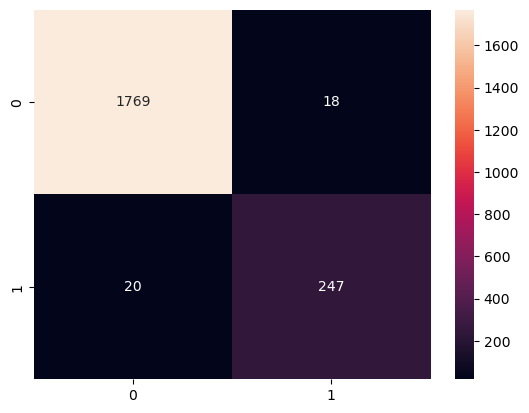

In [78]:
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="d")
plt.show()

In [79]:
svm = SVC(C=10, kernel='linear', class_weight='balanced')
scores = cross_val_score(svm, X_train, y_train, cv=cv)
print(f"{scores.mean()}")

0.9763822825999983


In [80]:
svm.fit(X_train, y_train)

SVC(C=10, class_weight='balanced', kernel='linear')

In [81]:
y_pred = svm.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy = {accuracy}")

Accuracy = 0.9771178188899707


In [85]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1787
           1       0.91      0.92      0.91       267

    accuracy                           0.98      2054
   macro avg       0.95      0.95      0.95      2054
weighted avg       0.98      0.98      0.98      2054



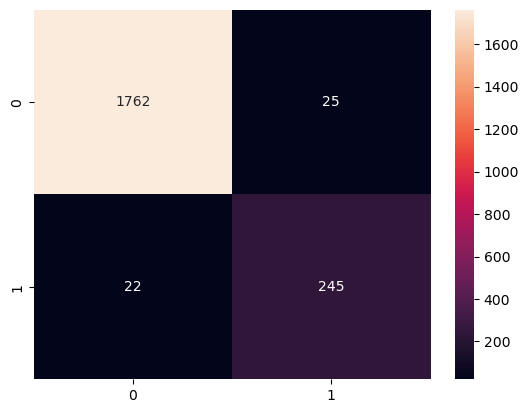

In [86]:
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="d")
plt.show()

In [87]:
knn = KNeighborsClassifier(n_neighbors=3)
score = cross_val_score(knn, X_train, y_train, cv=cv)
print(f"{scores.mean()}")

0.9763822825999983


In [88]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [89]:
y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy = {accuracy}")

Accuracy = 0.9415774099318404


In [90]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1787
           1       0.97      0.57      0.72       267

    accuracy                           0.94      2054
   macro avg       0.96      0.78      0.84      2054
weighted avg       0.94      0.94      0.93      2054



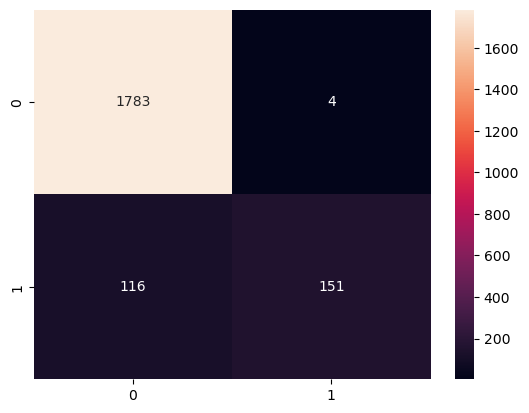

In [91]:
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt="d")
plt.show()

In [92]:
joblib.dump(logistic, 'model_v1.pkl')

['model_v1.pkl']